In [16]:
from datasets import load_dataset

print("Datasets library imported successfully!")

Datasets library imported successfully!


In [17]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [18]:
from datasets import load_dataset

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [19]:
train_df = dataset["train"].to_pandas()

In [20]:
print(dataset["train"][:5])

{'text': ['"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', '"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"', 'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.', "Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays", '@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"'], 'label': [2, 1, 1, 1, 2]}


In [21]:
print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['negative', 'neutral', 'positive'])}


In [22]:
from collections import Counter

labels = dataset["train"]["label"]

print(Counter(labels))

Counter({1: 20673, 2: 17849, 0: 7093})


In [23]:
for i in range(5):
    print("Text:", dataset["train"][i]["text"])
    print("Label:", dataset["train"][i]["label"])
    print("-" * 60)

Text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Label: 2
------------------------------------------------------------
Text: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
Label: 1
------------------------------------------------------------
Text: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
Label: 1
------------------------------------------------------------
Text: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
Label: 1
------------------------------------------------------------
Text: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
Label: 2
------------------------------------------------------------


In [24]:
import pandas as pd

train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Testing:", len(test_df))

Training: 45615
Validation: 2000
Testing: 12284


In [25]:
print(train_df.isnull().sum())

text     0
label    0
dtype: int64


In [26]:
print("Number of duplicate tweets:",
      train_df["text"].duplicated().sum())

Number of duplicate tweets: 29


In [27]:
train_df["text_length"] = train_df["text"].str.len()

print(train_df["text_length"].describe())

count    45615.000000
mean       106.932851
std         26.251517
min         10.000000
25%         89.000000
50%        113.000000
75%        128.000000
max        200.000000
Name: text_length, dtype: float64


In [29]:
print(train_df.columns)

Index(['text', 'label', 'text_length'], dtype='object')


In [30]:
label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

train_df["sentiment"] = train_df["label"].map(label_names)

print(train_df.head())

                                                text  label  text_length  \
0  "QT @user In the original draft of the 7th boo...      2          119   
1  "Ben Smith / Smith (concussion) remains out of...      1           84   
2  Sorry bout the stream last night I crashed out...      1          124   
3  Chase Headley's RBI double in the 8th inning o...      1          139   
4  @user Alciato: Bee will invest 150 million in ...      2          114   

  sentiment  
0  Positive  
1   Neutral  
2   Neutral  
3   Neutral  
4  Positive  


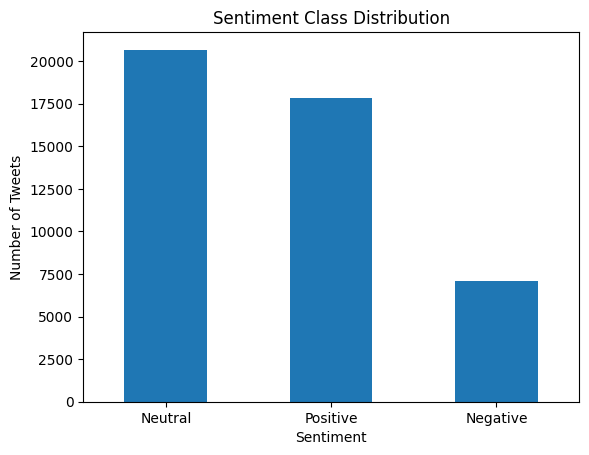

In [31]:
import matplotlib.pyplot as plt

sentiment_counts = train_df["sentiment"].value_counts()

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.show()

In [32]:
print(
    train_df.groupby("sentiment")["text_length"].mean()
)

sentiment
Negative    112.123925
Neutral     105.988294
Positive    105.963976
Name: text_length, dtype: float64


In [33]:
print("Shortest tweet length:",
      train_df["text_length"].min())

print("Longest tweet length:",
      train_df["text_length"].max())

Shortest tweet length: 10
Longest tweet length: 200


In [34]:
for sentiment in ["Negative", "Neutral", "Positive"]:
    print("\n==============================")
    print(sentiment)
    print("==============================")
    
    samples = train_df[train_df["sentiment"] == sentiment]["text"].head(3)
    
    for text in samples:
        print("-", text)


Negative
- So disappointed in wwe summerslam! I want to see john cena wins his 16th title
- That sucks if you have to take the SATs tomorrow
- Amy Schumer sat down with The Hollywood Reporter and opened up about the sexist remarks and unnecessary criticism she's faced since

Neutral
- "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
- Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
- Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays

Positive
- "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
- @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
- @user LIT MY MUM 'Kerry the louboutins I wonder how many Willam owns!!! Look Kerry Warner Wednesday!'


In [35]:
train_df.to_csv(
    "../data/raw/tweet_eval_sentiment_train.csv",
    index=False
)

print("EDA dataset saved successfully.")

EDA dataset saved successfully.
